# 05 SpaceX Falcon 9 - Exploratory Data Analysis & Visualization

This notebook is **Step 05** in a multi-step end-to-end data science project that analyzes and predicts **first-stage landing success** for SpaceX Falcon 9 launches.

In this step we:

- run visual EDA to understand how landing success (`Class`) relates to time (flight number/year), payload mass, launch site, and orbit

- create an ML-ready feature matrix by one-hot encoding key categorical variables for downstream modeling

**Pipeline overview:**

- **Step 01:** Collect launch data from the SpaceX REST API and create an initial modeling dataset.

- **Step 02:** Scrape a *fixed Wikipedia revision* of Falcon 9 & Falcon Heavy launch tables and export a clean CSV for supplementary analysis.

- **Step 03:** Clean and engineer features, create the landing success label (`Class`) and export the modeling dataset.

- **Step 04:** Load the labeled dataset into SQLite and explore patterns with SQL.

- **Step 05 (this notebook):** Visual EDA + one-hot encoding for modeling.

- **Next steps:** Interactive map (Folium), dashboarding (Dash), and machine learning modeling.

**Input:** `../data/processed/03_dataset_part_2.csv` (from Step 03)

**Primary output:** `../data/processed/05_dataset_part_3.csv` (one-hot encoded features for modeling)

## Notebook sections

**1. Setup**

**2. Load labeled dataset**

**3. Visual EDA**

**4. Feature engineering for modeling**

**5. Export artifacts**

**6. Assumptions**

---

## 1. Setup

Use pandas/numpy for data handling and seaborn/matplotlib for plotting.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents = True, exist_ok = True)

INPUT_CSV = PROCESSED_DIR / '03_dataset_part_2.csv'
OUTPUT_CSV = PROCESSED_DIR / '05_dataset_part_3.csv'

## 2. Load labeled dataset

We load the launch-level dataset produced in **step 03** (`03_dataset_part_2.csv`).

This dataset already includes a binary target label `Class` (1 = successful landing, 0 = failure).

In [2]:
df = pd.read_csv(INPUT_CSV)

df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


## 3. Visual EDA

Below are a few **focused visual checks** to understand how landing success varies across time, sites, payloads, and orbits.

### 3.1 Payload mass vs flight number

Use **FlightNumber** as a rough proxy for time (later flights tend to occur later in the program).

(Colored by landing success.)

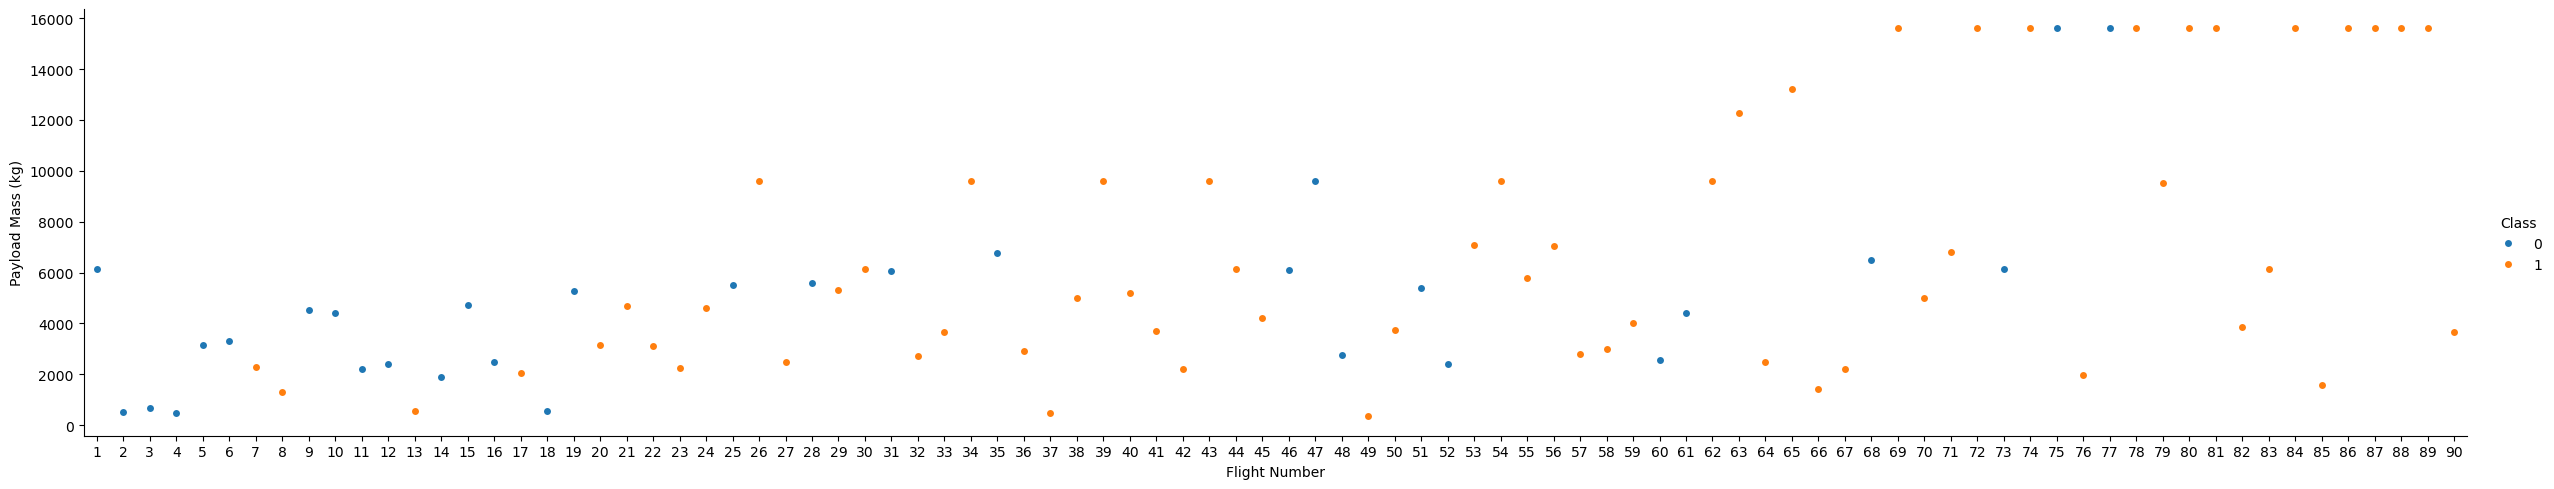

In [3]:
sns.catplot( y ='PayloadMass', x = 'FlightNumber', hue = 'Class', data = df, aspect = 5)
plt.xlabel('Flight Number')
plt.ylabel('Payload Mass (kg)')
plt.show()

### 3.2 Flight number vs launch site

This helps compare **site-specific** performance and how success evolves over the program's lifetime.


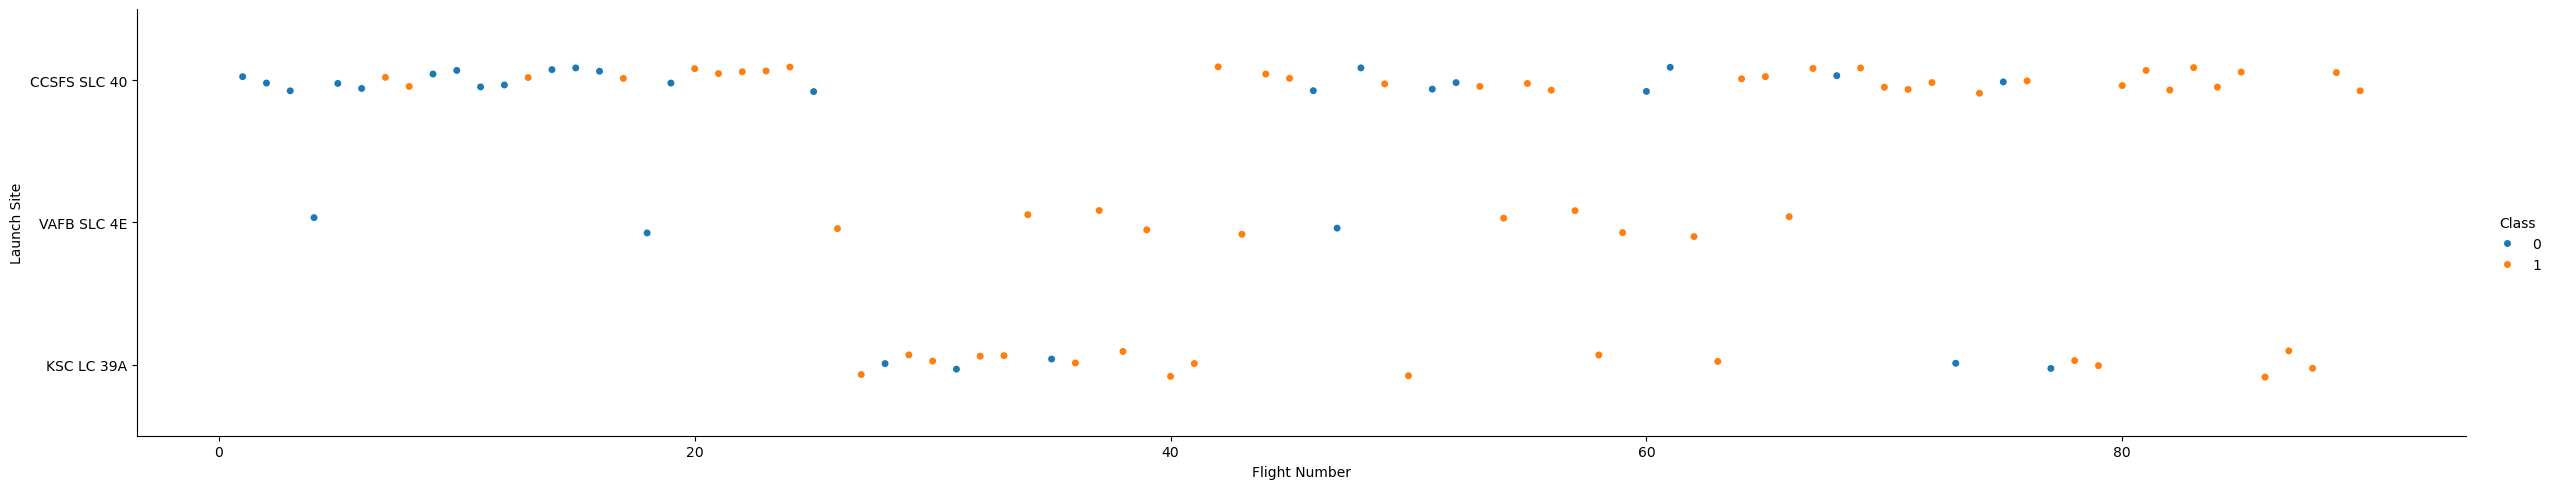

In [4]:
sns.catplot(y = 'LaunchSite', x = 'FlightNumber', hue = 'Class', data = df, aspect = 5)
plt.xlabel('Flight Number')
plt.ylabel('Launch Site')
plt.show()

### 3.3 Payload mass vs launch site

This highlights whether some sites are used more for **heavy payload** missions and whether payload relates to landing success.

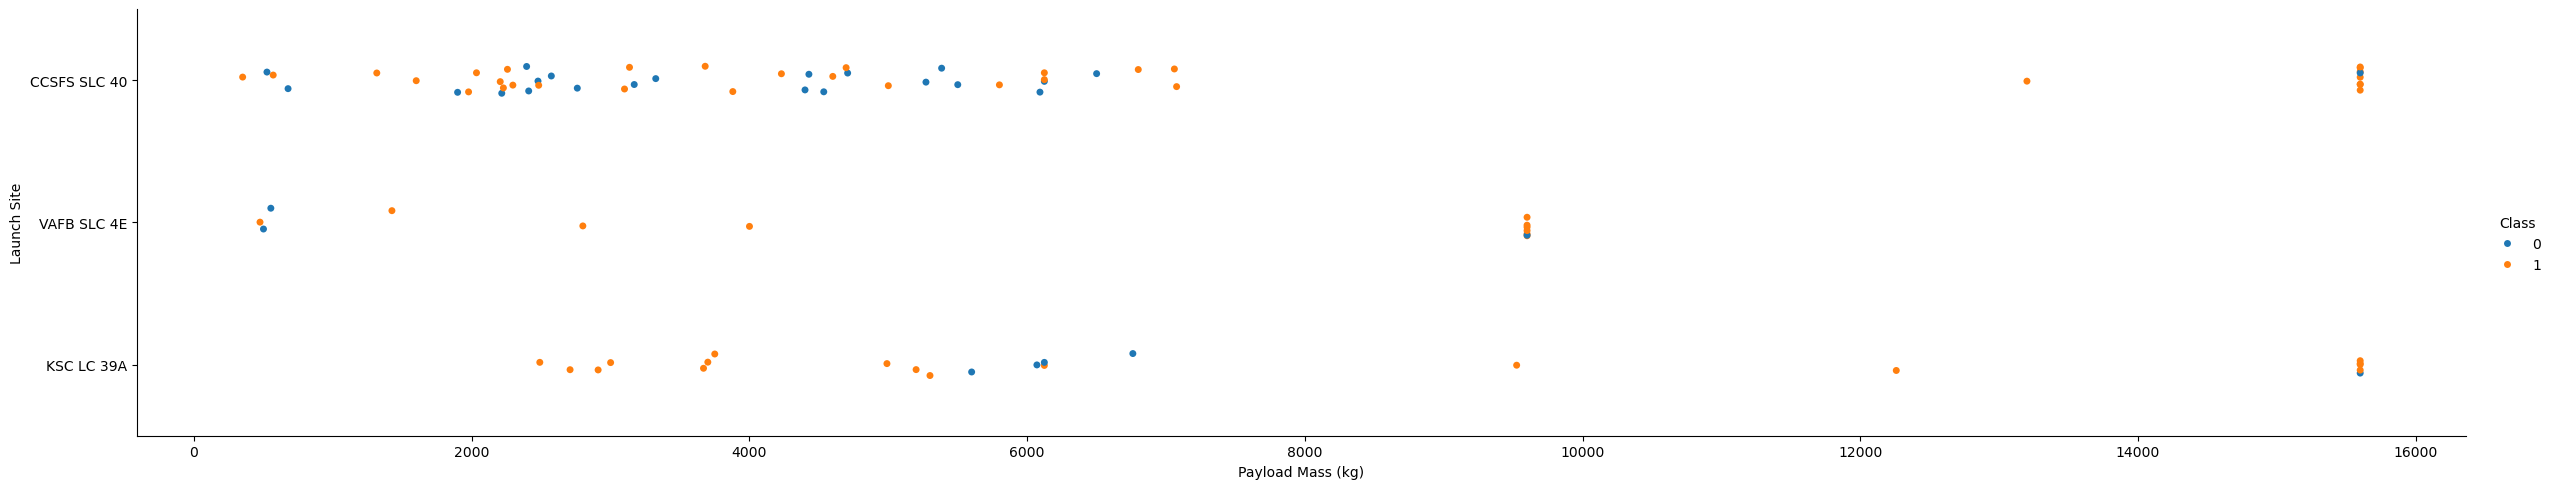

In [5]:
sns.catplot(y = 'LaunchSite', x = 'PayloadMass', hue = 'Class', data = df, aspect = 5)
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Launch Site')
plt.show()

*Interpretation note:* some sites may have limited payload ranges or mission profiles, which can affect observed success rates.

### 3.4 Success rate by orbit

We aggregate `Class` by `Orbit` to compare average success rates.

The below is a `bar chart` for the same success rate of each orbit.

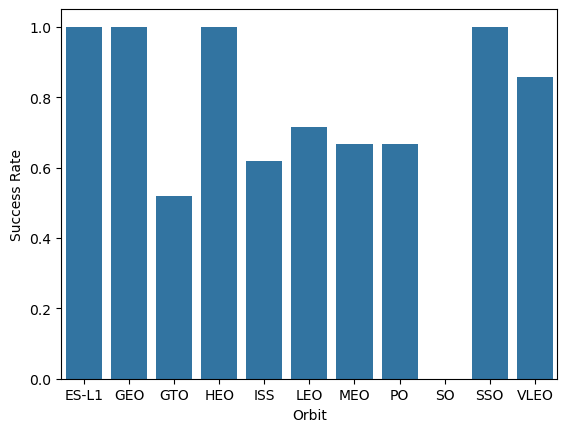

In [6]:
orbit_success = df.groupby('Orbit')['Class'].mean().reset_index()
sns.barplot(x = 'Orbit', y = 'Class', data = orbit_success)
plt.xlabel('Orbit')
plt.ylabel('Success Rate')
plt.show()

### 3.5 Flight number vs orbit

A quick check of whether success improves over time within specific orbit families.

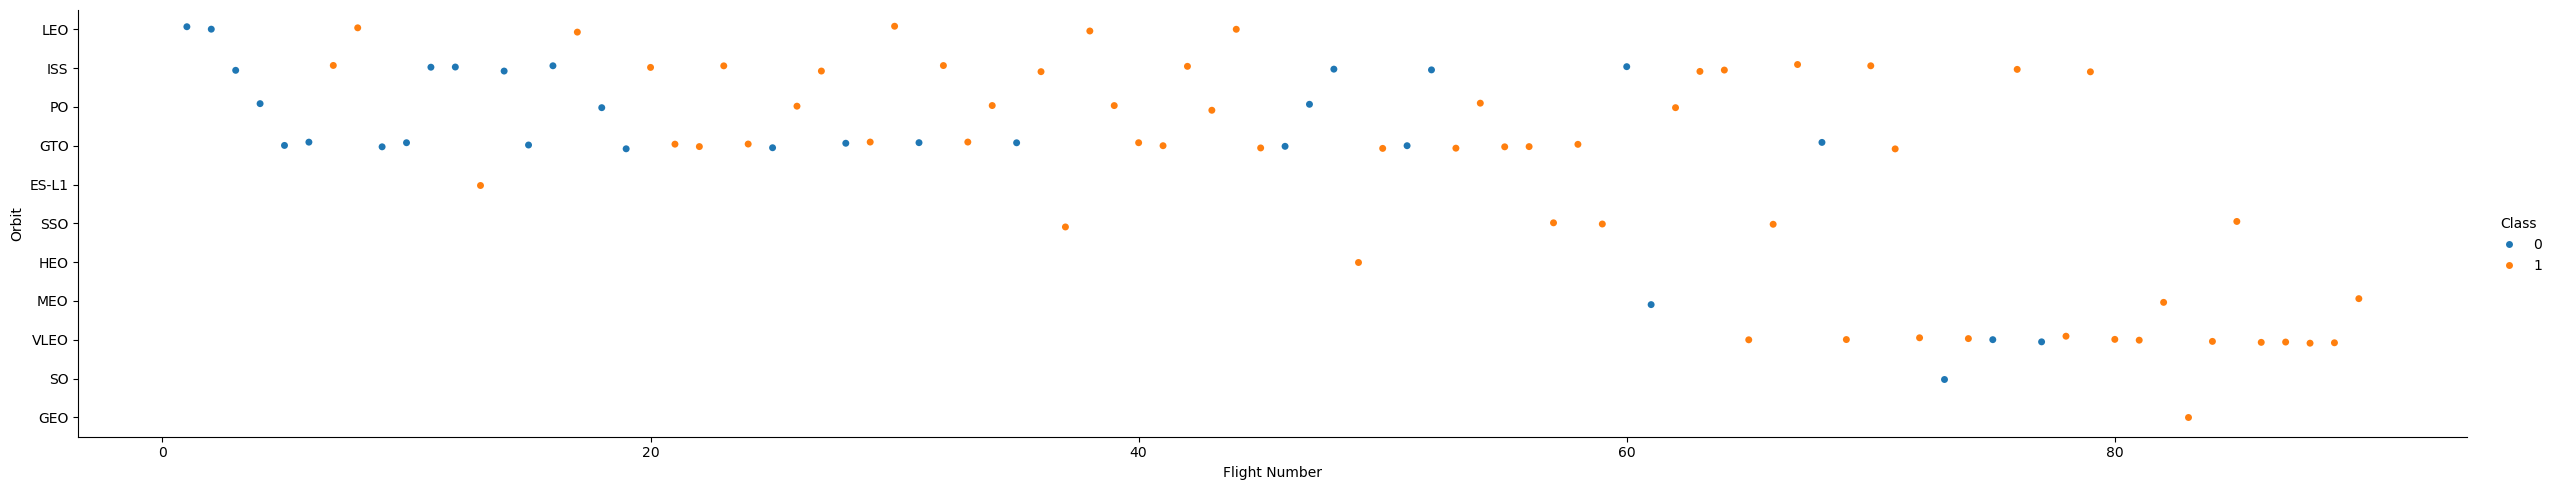

In [7]:
sns.catplot(y = 'Orbit', x = 'FlightNumber', hue = 'Class', data = df, aspect = 5)
plt.xlabel('Flight Number')
plt.ylabel('Orbit')
plt.show()

*Interpretation note:* increasing success over flight number is consistent with operational learning and iteration.

### 3.6 Payload mass vs orbit

This helps reveal orbit-payload combinations where landings are more/less likely to succeed.

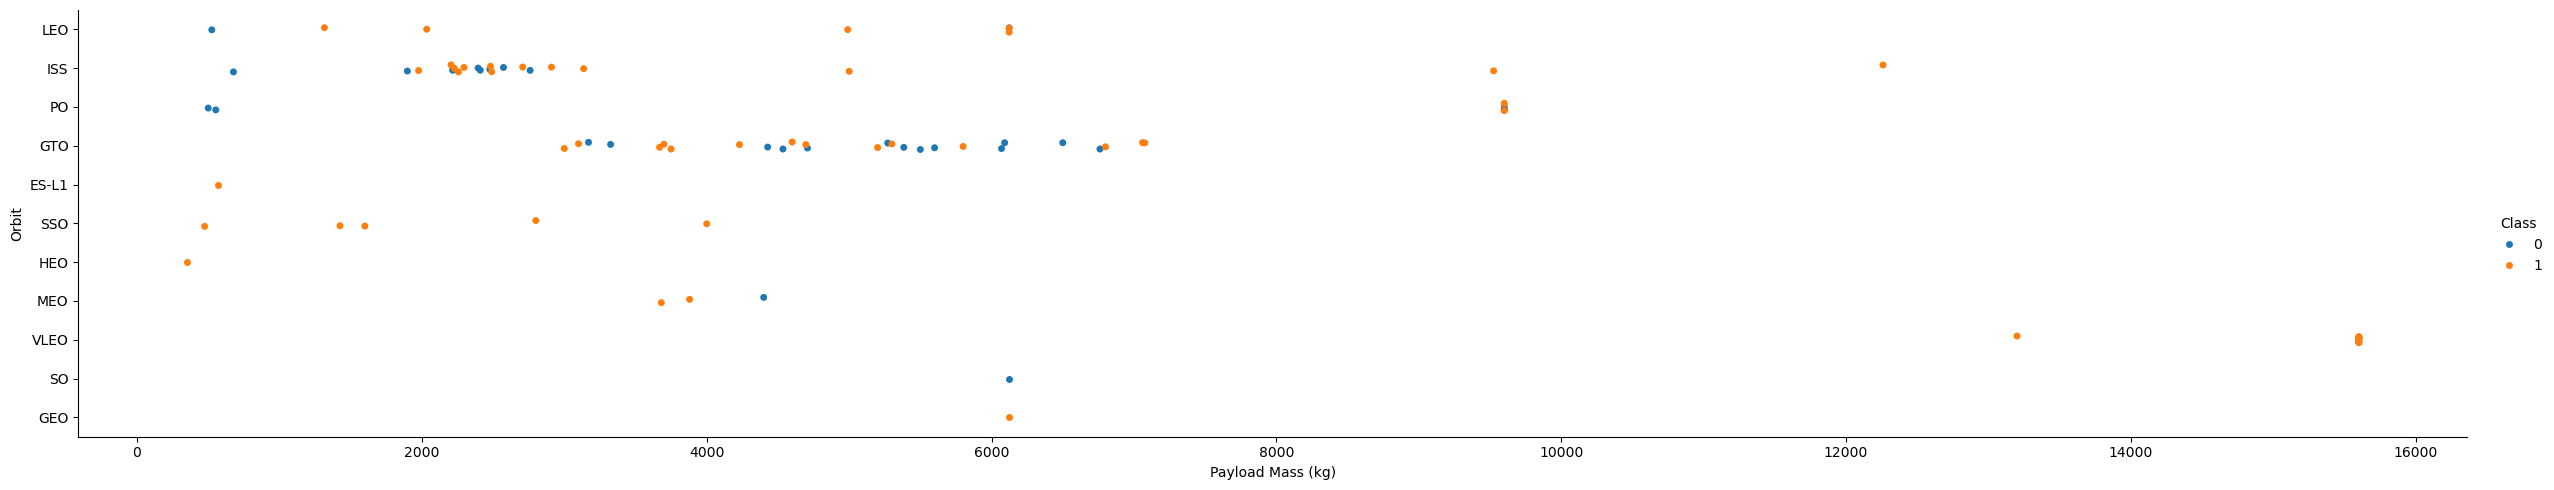

In [8]:
sns.catplot(y = 'Orbit', x = 'PayloadMass', hue = 'Class', data = df, aspect = 5)
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Orbit')
plt.show()

### 3.7 Yearly success trend

We extract the year from `Date`, then plot average yearly landing success.

In [9]:
# Helper function to extract year from date
year = []
def Extract_year(date):
    for i in df['Date']:
        year.append(i.split('-')[0])
    return year

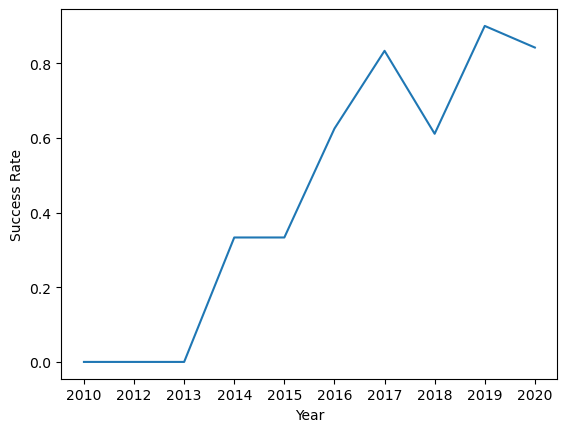

In [10]:
year = Extract_year(df['Date'])
df['Year'] = year
yearly_success = df.groupby('Year')['Class'].mean().reset_index()
sns.lineplot(x = 'Year', y = 'Class', data = yearly_success)
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.show()

## Quick takeaways (visual EDA)

Based on the dataset in this repo:

- **Learning over time:** yearly success rises sharply after 2013 (e.g. ~0% in 2013, ~83% in 2017, ~84% in 2020).

- **Launch site differences:** KSC LC 39A and VAFB SLC 4E show higher average success (~77%) than CCSFS SLC 40 (~60%).

- **Orbit differences:** success varies by orbit (e.g., ISS ~62% vs GTO ~52%). Some orbits show 100% success but have **very small samples** (n = 1), so treat those as anecdotal.

- **Time is a strong confounder:** higher flight numbers coincide with later years, where success is generally higher.

## 4. Feature engineering for modeling

We build this feature matrix used in the classification models later in the project (step 08) by one-hot encoding categorical variables.

In [11]:
features = df[[
    'FlightNumber',
    'PayloadMass',
    'Orbit',
    'LaunchSite',
    'Flights',
    'GridFins',
    'Reused',
    'Legs',
    'LandingPad',
    'Block',
    'ReusedCount',
    'Serial']]

features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6123.547647,LEO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### 4.1 One-hot encode categorical variables

We one-hot encode `Orbit`, `LaunchSite`, `LandingPad`, and `Serial` to obtain an all-numeric feature matrix.

In [12]:
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6123.547647,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### 4.2 Cast features to `float64`

Casting ensures a consistent numeric dtype for downstream ML pipelines.

In [13]:
features_one_hot = features_one_hot.astype('float64')
features_one_hot.dtypes

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 80, dtype: object

## 5. Export artifacts

We write one artifact to `../data/processed` for downstream modeling: `05_dataset_part_3.csv` One-hot encoded feature matrix (X) used in the classification models (08).

In [14]:
features_one_hot.to_csv(OUTPUT_CSV, index = False)

## 6. Assumptions

- Uses Step 03 output `../data/processed/03_dataset_part_2.csv` as the labeled launch-level dataset.

- `Class` is binary: 1 = successful first-stage landing, 0 = unsuccessful.

- `FlightNumber` and extracted year are treated as time proxies; patterns can be confounded by program maturity and changing mission mix.

- Visual results are descriptive (not causal); small group sizes can make some success rates noisy.

- One-hot encoding produces an all-numeric feature matrix; scaling (if needed) is handled in the modeling step.

---